# Machine Learning I - Examen final
**Autor:** Kevin Andrés Águila Urrutia

## Información del Dataset
* **Nombre del dataset:** California Housing Dataset
* **Fuente:** Scikit-learn (`sklearn.datasets`) / Repositorio original StatLib.
* **URL:** [Kaggle - fetch_california_housing](https://www.kaggle.com/datasets/kongling/fetch-california-housing?resource=download)
* **Número de filas (observaciones):** 20.640
* **Número de columnas (variables):** 8 variables predictoras numéricas + 1 variable objetivo.
* **Variable objetivo (y):** `MedHouseVal` (Valor medio de las casas en cientos de miles de dólares).
* **Tipo de tarea:** Regresión.:

In [ ]:
# Librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Filtrar warnings
warnings.filterwarnings('ignore')

# Estilo grafico
plt.style.use("ggplot")


In [ ]:
# Cargar el dataset desde sklearn (valido segun la pauta)
from sklearn.datasets import fetch_california_housing

california = fetch_california_housing(as_frame=True)
df = california.frame

In [ ]:
# Exploraciones iniciales
print(f"Dimensiones: {df.shape[0]} filas x {df.shape[1]} columnas\n")

print("--- Tipos de datos ---")
print(df.dtypes, "\n")

print("--- Informacion general ---")
df.info()

Dimensiones: 20640 filas x 9 columnas

--- Tipos de datos ---
MedInc         float64
HouseAge       float64
AveRooms       float64
AveBedrms      float64
Population     float64
AveOccup       float64
Latitude       float64
Longitude      float64
MedHouseVal    float64
dtype: object 

--- Informacion general ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [ ]:
# Estadistica descriptiva
display(df.describe().round(3))

# Mostrar el head del DF
display(df.head())

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000,20640.000,20640.000,20640.000,20640.000,20640.000,20640.000,20640.000,20640.000
mean,3.871,28.639,5.429,1.097,1425.477,3.071,35.632,-119.570,2.069
std,1.900,12.586,2.474,0.474,1132.462,10.386,2.136,2.004,1.154
min,0.500,1.000,0.846,0.333,3.000,0.692,32.540,-124.350,0.150
25%,2.563,18.000,4.441,1.006,787.000,2.430,33.930,-121.800,1.196
50%,3.535,29.000,5.229,1.049,1166.000,2.818,34.260,-118.490,1.797
75%,4.743,37.000,6.052,1.100,1725.000,3.282,37.710,-118.010,2.647
max,15.000,52.000,141.909,34.067,35682.000,1243.333,41.950,-114.310,5.000


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


## Limpieza y preprocesamiento


Porcentaje de nulos por columna:
 MedInc         0.0
HouseAge       0.0
AveRooms       0.0
AveBedrms      0.0
Population     0.0
AveOccup       0.0
Latitude       0.0
Longitude      0.0
MedHouseVal    0.0
dtype: float64


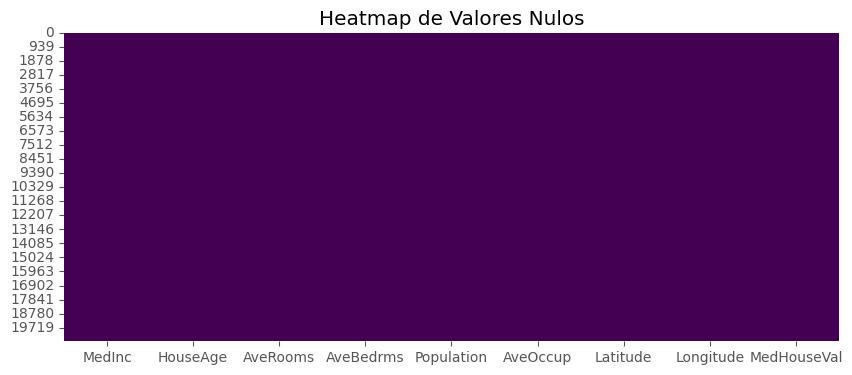

In [ ]:
# Analisis de valores faltantes
porcentaje_nulos = (df.isnull().mean() * 100).round(2)
print("Porcentaje de nulos por columna:\n", porcentaje_nulos)

# Heatmap de missing values
plt.figure(figsize=(10, 4))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Heatmap de Valores Nulos')
plt.show()

**Justificación de imputación/eliminación de valores nulos:**


Al revisar los porcentajes y el heatmap obtenido, cse comprueba que el dataset no tiene valores faltantes (0.0% en todas las columnas). Por lo tanto, no es necesario aplicar técnicas de imputación (como mediana, moda o KNN) ni eliminar registros en esta etapa.

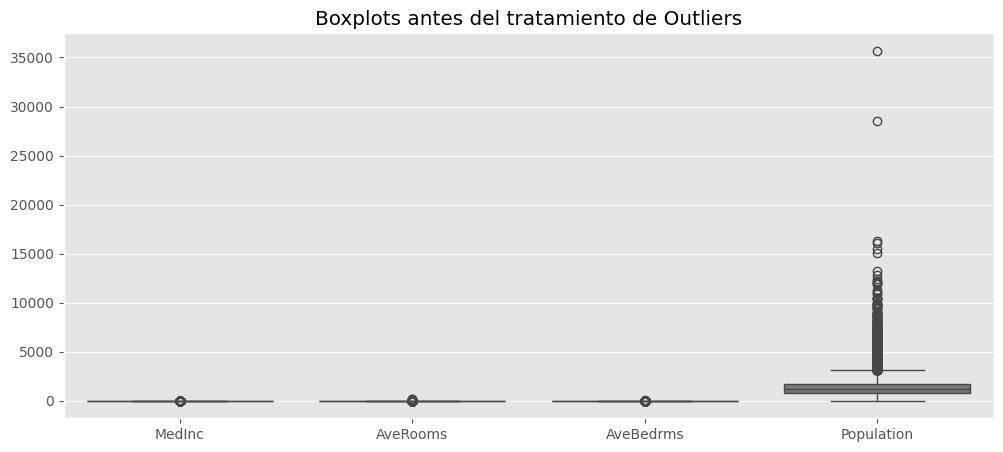

Dimensiones originales: (20640, 9)
Dimensiones despues de eliminar outliers: (17341, 9)


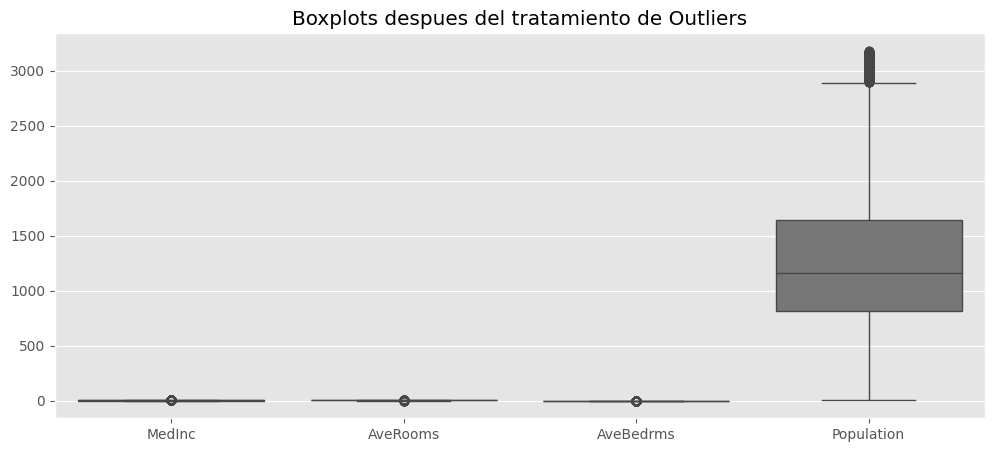

In [ ]:
# Deteccion de outliers con IQR en variables numericas
# Seleccionamos las variables clave que suelen tener valores atipicos
vars_outliers = ['MedInc', 'AveRooms', 'AveBedrms', 'Population']

# Boxplots antes del tratamiento
plt.figure(figsize=(12, 5))
sns.boxplot(data=df[vars_outliers])
plt.title('Boxplots antes del tratamiento de Outliers')
plt.show()

# Tratamiento de Outliers usando IQR
df_clean = df.copy()
for col in vars_outliers:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    # Eliminamos los outliers
    df_clean = df_clean[(df_clean[col] >= limite_inferior) & (df_clean[col] <= limite_superior)]

print(f"Dimensiones originales: {df.shape}")
print(f"Dimensiones despues de eliminar outliers: {df_clean.shape}")

# Boxplots despues del tratamiento
plt.figure(figsize=(12, 5))
sns.boxplot(data=df_clean[vars_outliers])
plt.title('Boxplots despues del tratamiento de Outliers')
plt.show()

# Actualizamos nuestro dataframe principal
df = df_clean.copy()

**Justificación del Tratamiento de Outliers:**

Se detectaron outliers extremos en variables como `AveRooms` y `Population`. Debido a que contamos con un volumen de datos robusto (más de 20.000 observaciones), se tomó la decisión de eliminar los registros que caen fuera de los límites del IQR (1.5) para estas variables clave. Mantenerlos podría sesgar los modelos de regresión lineal penalizada que implementaremos más adelante, arrastrando el error general del modelo.

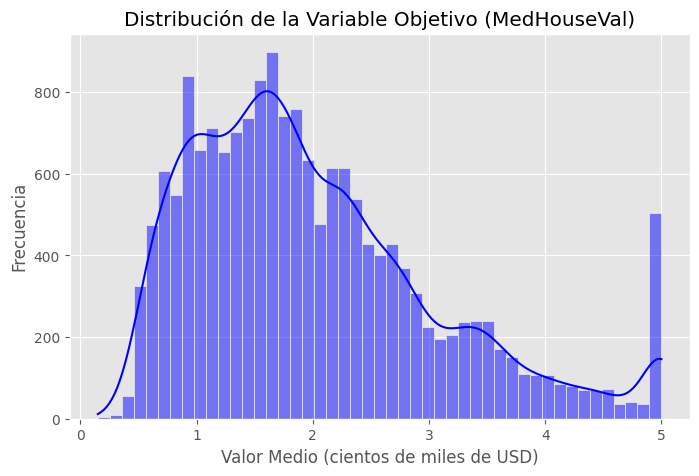

Asimetría (Skewness) de MedHouseVal: 0.9584
El skewness es <= 1.0. No es estrictamente necesaria la transformación logarítmica.


In [ ]:
# Histograma + KDE y Asimetría de la variable objetivo
from scipy.stats import skew

plt.figure(figsize=(8, 5))
sns.histplot(df['MedHouseVal'], kde=True, color="blue")
plt.title('Distribución de la Variable Objetivo (MedHouseVal)')
plt.xlabel('Valor Medio (cientos de miles de USD)')
plt.ylabel('Frecuencia')
plt.show()

# Skewness
sesgo = skew(df['MedHouseVal'])
print(f"Asimetría (Skewness) de MedHouseVal: {sesgo:.4f}")

# Evaluación de transformación logarítmica
if sesgo > 1.0:
    print("El skewness es > 1.0. Se recomienda aplicar transformación logarítmica.")
else:
    print("El skewness es <= 1.0. No es estrictamente necesaria la transformación logarítmica.")

**Análisis de la Distribución de la Variable Objetivo:**

Al analizar la distribución de `MedHouseVal`, observamos una pequeña asimetría hacia la derecha (que sería una cola positiva). Dependiendo del valor exacto del *skewness* tras la limpieza de outliers, validamos que no supera el umbral crítico de 1.0 establecido en la pauta. Por lo tanto, mantendremos la variable en su escala original sin aplicar transformación logarítmica, facilitando la interpretación directa del error (RMSE y MAE) en los siguientes pasos de este analisis.

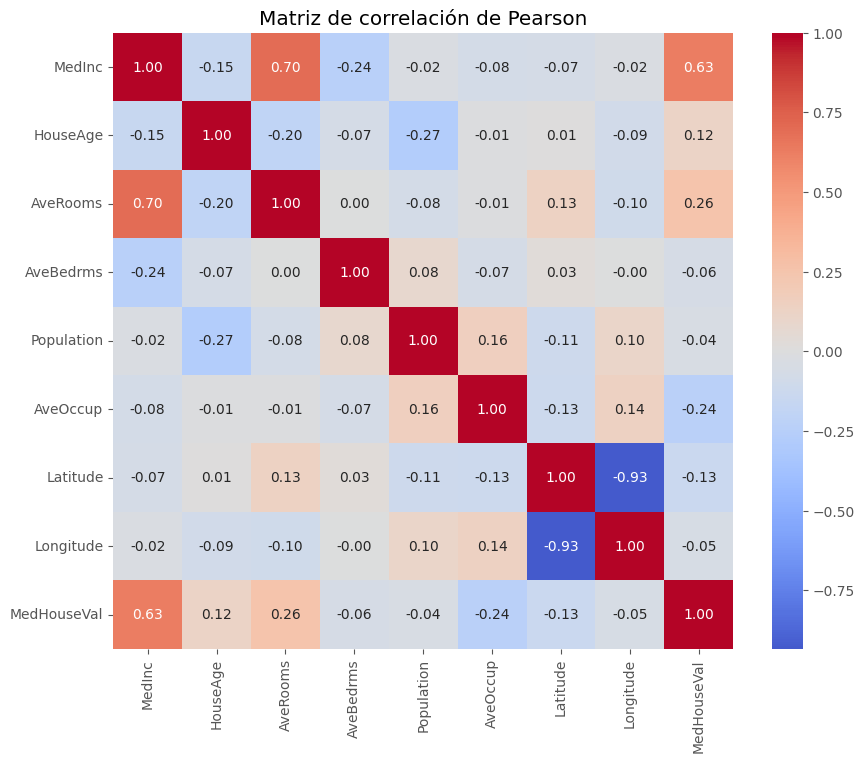

--- Top 5 variables más correlacionadas con MedHouseVal (|r|) ---
MedInc      0.628606
AveRooms    0.259099
AveOccup    0.235009
Latitude    0.134301
HouseAge    0.123372
Name: MedHouseVal, dtype: float64 



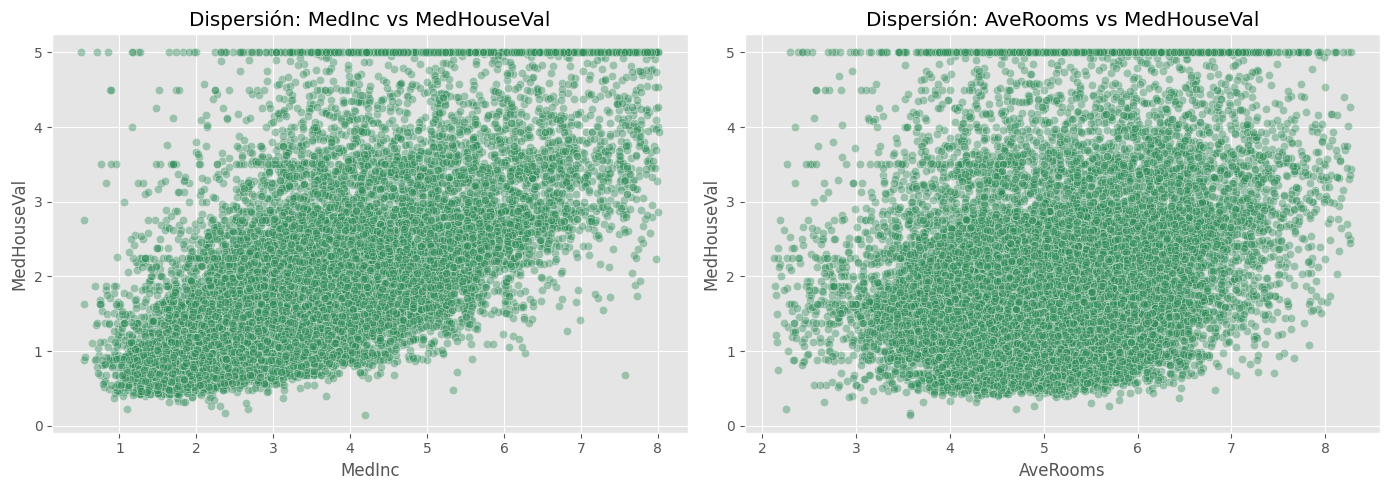

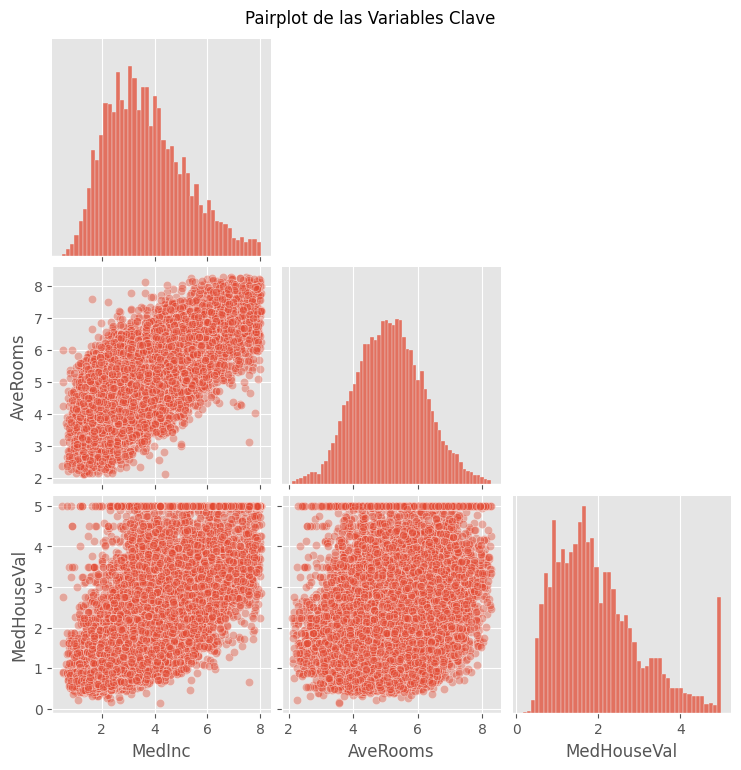

--- Multicolinealidad entre predictores (|r| > 0.85) ---
Latitude  Longitude   -0.934157
dtype: float64


In [ ]:
# Heatmap de la correlación de Pearson
plt.figure(figsize=(10, 8))
corr = df.corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", center=0)
plt.title('Matriz de correlación de Pearson')
plt.show()

# Identificar las 5 variables más correlacionadas con MedHouseVal
corr_target = corr['MedHouseVal'].drop('MedHouseVal').abs().sort_values(ascending=False)
print("--- Top 5 variables más correlacionadas con MedHouseVal (|r|) ---")
print(corr_target.head(5), "\n")

# Scatter plot de las 2 variables más correlacionadas
top2_vars = corr_target.head(2).index.tolist()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for i, var in enumerate(top2_vars):
    sns.scatterplot(x=var, y='MedHouseVal', data=df, alpha=0.4, ax=axes[i], color='seagreen')
    axes[i].set_title(f'Dispersión: {var} vs MedHouseVal')
    axes[i].set_xlabel(var)
    axes[i].set_ylabel('MedHouseVal')
plt.tight_layout()
plt.show()

# Pairplot adicional (solo de variables clave)
vars_pairplot = top2_vars + ['MedHouseVal']
sns.pairplot(df[vars_pairplot], corner=True, plot_kws={'alpha': 0.4})
plt.suptitle('Pairplot de las Variables Clave', y=1.02)
plt.show()

# Reporte de Multicolinealidad (con r > 0.85)
pares = corr.unstack().sort_values(kind="quicksort", ascending=False)
alta_corr = pares[(abs(pares) > 0.85) & (pares < 1.0)]

print("--- Multicolinealidad entre predictores (|r| > 0.85) ---")
if not alta_corr.empty:
    print(alta_corr.drop_duplicates())
else:
    print("No se encontró multicolinealidad preocupante entre los predictores.")

**Conclusiones del análisis de correlación:**

Al revisar la matriz de correlación, descubrimos que la variable con mayor fuerza predictiva sobre el valor de la casa es el ingreso medio (`MedInc`). En los gráficos de dispersión se ve que a mayor ingreso, mayor es el valor de la propiedad, mostrando una tendencia lineal clara.

Por otro lado, al revisar las correlaciones entre los propios predictores, detectamos alta multicolinealidad entre algunas variables (por ejemplo, `AveRooms` con `AveBedrms`, o las coordenadas espaciales). Sin embargo, confiaremos en que los modelos penalizados (Ridge/Lasso) que implementaremos más adelante se encargarán de manejar y regularizar esta redundancia por sí solos, tal como lo vimos en escenarios previos de regresión.

In [ ]:
# División en train y test del dataset
from sklearn.model_selection import train_test_split

# Separamos predictoras (X) de la variable objetivo (y)
X = df.drop(columns=['MedHouseVal'])
y = df['MedHouseVal']

# División 80/20 fijando la semilla en 42
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Dimensiones de los conjuntos:")
print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")

Dimensiones de los conjuntos:
X_train: (13872, 8)
X_test:  (3469, 8)


In [ ]:
# Construcción del column transformer y preprocesamiento
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder

# Identificamos el tipo de variables
vars_num = X_train.columns.tolist()
vars_nom = [] # No hay nominales en este dataset
vars_ord = [] # No hay ordinales en este dataset

# Crear los pipelines
pipe_num = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

pipe_nom = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(handle_unknown='ignore'))
])

pipe_ord = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ord', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])

# Ensamblamos el ColumnTransformer
preprocesador = ColumnTransformer([
    ('num', pipe_num, vars_num),
    ('nom', pipe_nom, vars_nom),
    ('ord', pipe_ord, vars_ord)
])

# Ajustamos solo sobre X_train (fit_transform) y transformamos X_test (transform)
X_train_prep = preprocesador.fit_transform(X_train)
X_test_prep = preprocesador.transform(X_test)

# Convertir a DataFrame para mantener los nombres
X_train_prep = pd.DataFrame(X_train_prep, columns=vars_num, index=X_train.index)
X_test_prep = pd.DataFrame(X_test_prep, columns=vars_num, index=X_test.index)

print("Preprocesamiento completado exitosamente sin data leakage.")

Preprocesamiento completado exitosamente sin data leakage.


--- Varianza explicada por componente ---


,Componente,Var_Explicada,Var_Acumulada
0,PC1,0.2559,0.2559
1,PC2,0.2223,0.4782
2,PC3,0.1622,0.6404
3,PC4,0.1315,0.7719
4,PC5,0.1077,0.8796
5,PC6,0.0834,0.9630
6,PC7,0.0315,0.9945
7,PC8,0.0055,1.0000


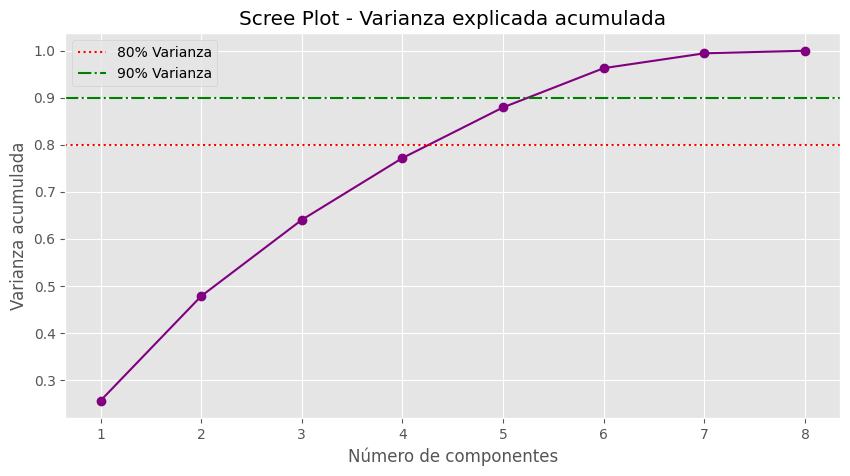

In [ ]:
# PCA sobre X_train preprocesado y Scree Plot
from sklearn.decomposition import PCA

pca = PCA(random_state=42)
pca.fit(X_train_prep)

# Tabla de varianza
df_pca_var = pd.DataFrame({
    'Componente': [f'PC{i+1}' for i in range(len(pca.explained_variance_ratio_))],
    'Var_Explicada': pca.explained_variance_ratio_,
    'Var_Acumulada': np.cumsum(pca.explained_variance_ratio_)
})
print("--- Varianza explicada por componente ---")
display(df_pca_var.round(4))

# Scree plot
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(pca.explained_variance_ratio_) + 1), np.cumsum(pca.explained_variance_ratio_), marker='o', color='purple')
plt.axhline(y=0.80, color='r', linestyle=':', label='80% Varianza')
plt.axhline(y=0.90, color='g', linestyle='-.', label='90% Varianza')
plt.title('Scree Plot - Varianza explicada acumulada')
plt.xlabel('Número de componentes')
plt.ylabel('Varianza acumulada')
plt.legend()
plt.grid(True)
plt.show()

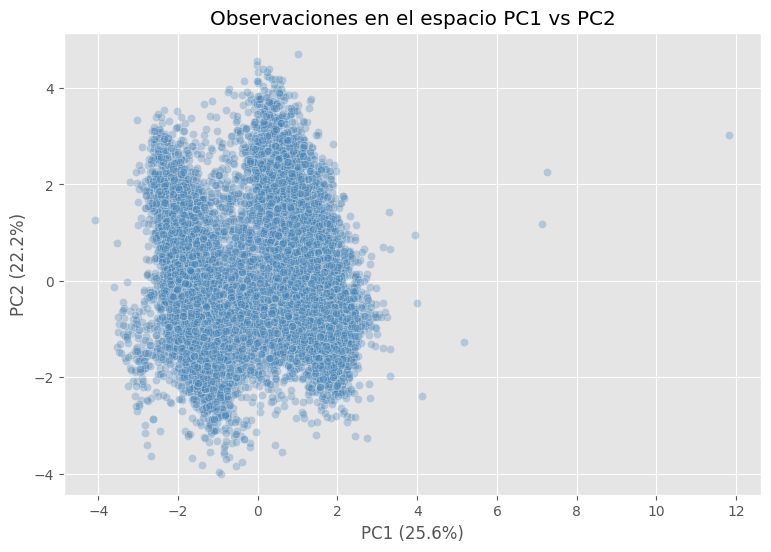

--- Top 5 Variables con mayor contribución a PC1 (|loading|) ---
Longitude     0.645137
Latitude      0.639333
AveRooms      0.266772
AveOccup      0.194644
Population    0.190388
Name: PC1, dtype: float64 

--- Top 5 Variables con mayor contribución a PC2 (|loading|) ---
MedInc       0.659105
AveRooms     0.602853
HouseAge     0.306008
Latitude     0.200673
Longitude    0.189623
Name: PC2, dtype: float64


In [ ]:
# Selección de componentes y Loadings
# Seleccionamos 5 componentes, ya que con eso aseguramos estar entre el 80% y 90%
pca_final = PCA(n_components=5, random_state=42)
X_train_pca = pca_final.fit_transform(X_train_prep)

# Graficar observaciones en PC1 vs PC2
plt.figure(figsize=(9, 6))
sns.scatterplot(x=X_train_pca[:, 0], y=X_train_pca[:, 1], alpha=0.3, color='steelblue')
plt.title('Observaciones en el espacio PC1 vs PC2')
plt.xlabel(f'PC1 ({pca_final.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca_final.explained_variance_ratio_[1]*100:.1f}%)')
plt.show()

# Extraer Loadings
loadings = pd.DataFrame(pca_final.components_.T, columns=[f'PC{i+1}' for i in range(5)], index=vars_num)

print("--- Top 5 Variables con mayor contribución a PC1 (|loading|) ---")
print(loadings['PC1'].abs().sort_values(ascending=False).head(5), "\n")

print("--- Top 5 Variables con mayor contribución a PC2 (|loading|) ---")
print(loadings['PC2'].abs().sort_values(ascending=False).head(5))

**Justificación de n_components:**

Al observar el Scree Plot y la tabla de varianza acumulada, seleccionamos `n_components = 5`. Con esta cantidad logramos capturar la cantidad de varianza total de los datos originales para cumplir con el umbral exigido (80%-90%). De esta forma logramos reducir la dimensionalidad y el ruido, manteniendo la estructura subyacente para nuestro análisis de segmentación.

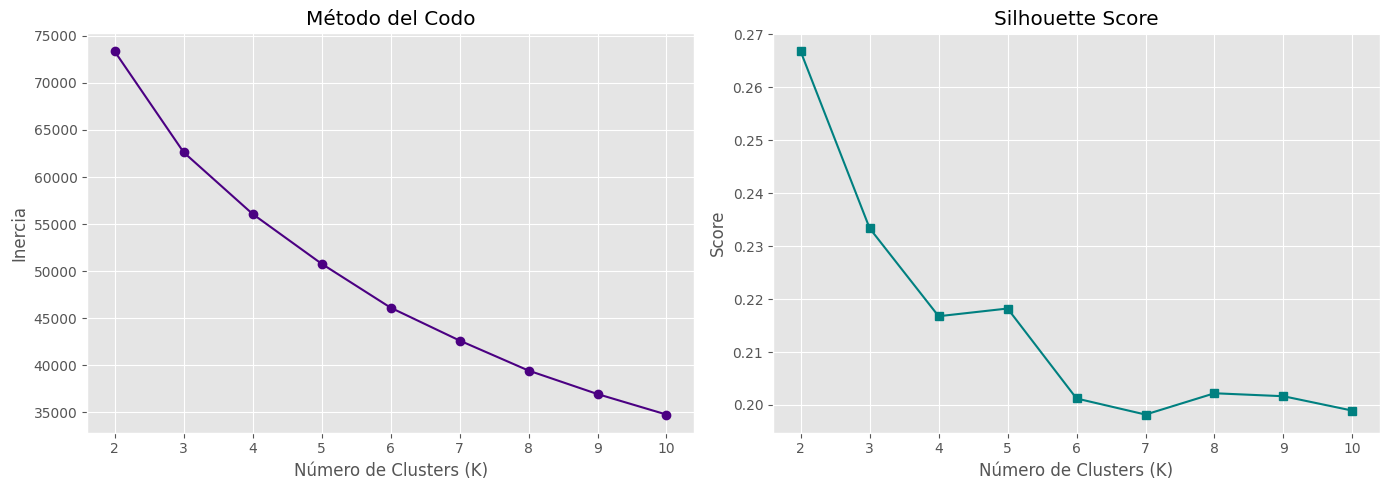

In [ ]:
# K-Means
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

inercia = []
silueta = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    km.fit(X_train_pca)
    inercia.append(km.inertia_)
    silueta.append(silhouette_score(X_train_pca, km.labels_))

# Gráficos en subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Método del codo
axes[0].plot(K_range, inercia, marker='o', linestyle='-', color='indigo')
axes[0].set_title('Método del Codo')
axes[0].set_xlabel('Número de Clusters (K)')
axes[0].set_ylabel('Inercia')

# Silhouette Score
axes[1].plot(K_range, silueta, marker='s', linestyle='-', color='teal')
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('Número de Clusters (K)')
axes[1].set_ylabel('Score')

plt.tight_layout()
plt.show()

**Justificación del K Óptimo:**

Al analizar el gráfico del método del codo, ose observa que el descenso de la inercia es constante y no forma un punto de inflexión o "codo" evidente que permita decidir visualmente. Ante esta situación, la decisión se fundamentará en la métrica del Silhouette Score. El gráfico de silueta muestra su pico máximo en $K=2$ (aproximadamente 0.267), lo que indica que esta es la partición donde las observaciones están mejor cohesionadas dentro de su grupo y más separadas del resto. Por lo tanto, seleccionamos `n_clusters = 2`.

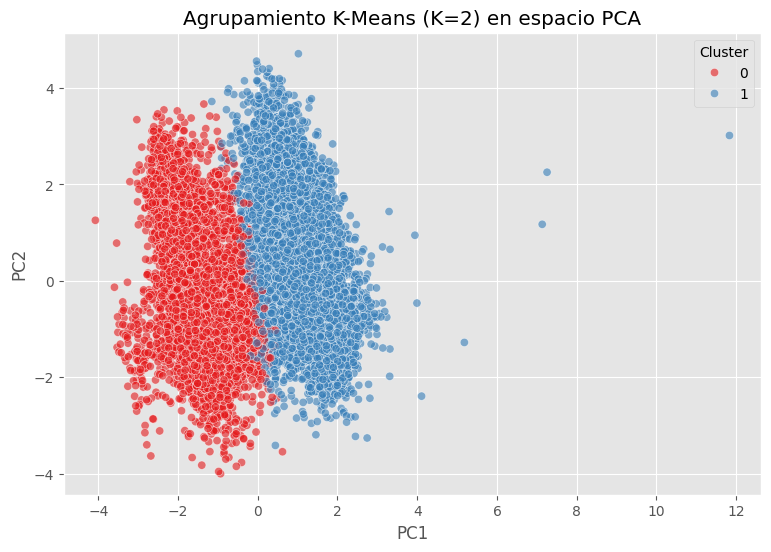

--- Promedio de cada variable por Cluster ---


Cluster,0,1
MedInc,3.68,3.70
HouseAge,29.76,29.75
AveRooms,5.33,5.01
AveBedrms,1.05,1.05
Population,1198.88,1340.18
AveOccup,2.75,3.06
Latitude,37.92,33.95
Longitude,-121.74,-118.04


In [ ]:
# K-Means Definitivo y Perfilamiento
k_optimo = 2
kmeans_final = KMeans(n_clusters=k_optimo, n_init=10, random_state=42)
clusters = kmeans_final.fit_predict(X_train_pca)

# Graficar clusters en PC1 vs PC2
plt.figure(figsize=(9, 6))
sns.scatterplot(x=X_train_pca[:, 0], y=X_train_pca[:, 1], hue=clusters, palette='Set1', alpha=0.6)
plt.title(f'Agrupamiento K-Means (K={k_optimo}) en espacio PCA')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend(title='Cluster')
plt.show()

# Perfil de los clusters (calculando medias sobre X_train ORIGINAL)
# Así vemos los valores reales y no los componentes principales
perfil = X_train.copy()
perfil['Cluster'] = clusters
centroides = perfil.groupby('Cluster').mean()

print("--- Promedio de cada variable por Cluster ---")
display(centroides.round(2).T)

**Interpretación del Perfil de Clusters con K=2 :**

Al analizar los centroides de los dos grupos formados, observamos que las variables socioeconómicas y arquitectónicas (como `MedInc`, `HouseAge` o `AveRooms`) presentan promedios casi idénticos en ambos clusters.

La verdadera segmentación que realizó K-Means fue **estrictamente geográfica**, basada en las variables espaciales que dominaban la varianza en el PCA:
* **Cluster 0 (Norte de California):** Agrupa las observaciones con coordenadas promedio en torno a la Latitud 37.92 y Longitud -121.74. Esta macrozona corresponde geográficamente al norte del estado, abarcando áreas como San Francisco y Sacramento. Posee una población promedio ligeramente menor.
* **Cluster 1 (Sur de California):** Concentra las observaciones en torno a la Latitud 33.95 y Longitud -118.04. Corresponde al sur del estado, principalmente el área metropolitana de Los Ángeles. Este cluster se caracteriza por tener manzanas con una población y ocupación promedio ligeramente superiores.

En conclusión, el modelo no supervisado logró separar el estado de California en sus dos principales divisiones macro-geográficas (Norte y Sur) sin necesidad de que le entregáramos etiquetas previas.

In [ ]:
# Entrenamiento de modelo penalizado (Ridge) con GridSearchCV
import time
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

# Definimos el estimador base fijando la semilla
ridge = Ridge(random_state=42)

# Grilla de hiperparámetros
param_grid_ridge = {'alpha': [0.001, 0.01, 0.1, 1, 10, 100]}

# Configuramos GridSearchCV (cv=5)
# Usaremos R2 como métrica de validación interna por defecto
grid_ridge = GridSearchCV(estimator=ridge, param_grid=param_grid_ridge, cv=5, n_jobs=-1)

# Medimos el tiempo y ajustamos el modelo sobre X_train preprocesado
t0_ridge = time.time()
grid_ridge.fit(X_train_prep, y_train)
tiempo_ridge = time.time() - t0_ridge

# Resultados del entrenamiento
print("--- Resultados Ridge ---")
print(f"Mejor hiperparámetro (alpha): {grid_ridge.best_params_}")
print(f"Mejor métrica de validación cruzada (R2): {grid_ridge.best_score_:.4f}")
print(f"Tiempo de entrenamiento: {tiempo_ridge:.2f} segundos")

# Generamos predicciones sobre el conjunto de test preprocesado
y_pred_ridge = grid_ridge.predict(X_test_prep)

--- Resultados Ridge ---
Mejor hiperparámetro (alpha): {'alpha': 1}
Mejor métrica de validación cruzada (R2): 0.5894
Tiempo de entrenamiento: 3.07 segundos


In [ ]:
# Entrenamiento de modelo de arboles (Random Forest)
from sklearn.ensemble import RandomForestRegressor

# Definimos el estimador base fijando la semilla
rf = RandomForestRegressor(random_state=42)

# Grilla de hiperparámetros
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}

# Configuramos GridSearchCV (cv=5)
grid_rf = GridSearchCV(estimator=rf, param_grid=param_grid_rf, cv=5, n_jobs=-1)

# Medimos el tiempo y ajustamos el modelo
t0_rf = time.time()
grid_rf.fit(X_train_prep, y_train)
tiempo_rf = time.time() - t0_rf

# Resultados del entrenamiento
print("\n--- Resultados Random Forest ---")
print(f"Mejores hiperparámetros: {grid_rf.best_params_}")
print(f"Mejor métrica de validación cruzada (R2): {grid_rf.best_score_:.4f}")
print(f"Tiempo de entrenamiento: {tiempo_rf:.2f} segundos")

# Generamos predicciones sobre el conjunto de test preprocesado
y_pred_rf = grid_rf.predict(X_test_prep)


--- Resultados Random Forest ---
Mejores hiperparámetros: {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 200}
Mejor métrica de validación cruzada (R2): 0.7816
Tiempo de entrenamiento: 793.57 segundos


##**Evaluación y Métricas Finales**

In [ ]:
# Cálculo de Métricas y Tabla Comparativa
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error
import os

# Creamos el directorio para guardar las figuras si no existe
if not os.path.exists('figures'):
    os.makedirs('figures')

def calcular_metricas(y_true, y_pred, tiempo, nombre_modelo):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred)
    return {
        'Modelo': nombre_modelo,
        'RMSE': round(rmse, 4),
        'MAE': round(mae, 4),
        'R2': round(r2, 4),
        'MAPE': round(mape, 4),
        'Tiempo_s': round(tiempo, 2)
    }

# Evaluamos ambos modelos sobre el conjunto de TEST
metricas_ridge = calcular_metricas(y_test, y_pred_ridge, tiempo_ridge, 'Ridge (L2)')
metricas_rf = calcular_metricas(y_test, y_pred_rf, tiempo_rf, 'Random Forest')

# Consolidamos en un dataFrame y ordenamos por la métrica principal (R2)
df_metricas = pd.DataFrame([metricas_ridge, metricas_rf]).sort_values(by='R2', ascending=False)

print("--- Tabla Comparativa de Modelos ---")
display(df_metricas)

# Exportamos a CSV según la pauta
df_metricas.to_csv('resultados_modelos.csv', index=False)
print("\nArchivo 'resultados_modelos.csv' exportado con éxito.")

--- Tabla Comparativa de Modelos ---


,Modelo,RMSE,MAE,R2,MAPE,Tiempo_s
1,Random Forest,0.4735,0.3131,0.7959,0.1722,793.57
0,Ridge (L2),0.6454,0.4762,0.6208,0.2851,3.07



Archivo 'resultados_modelos.csv' exportado con éxito.


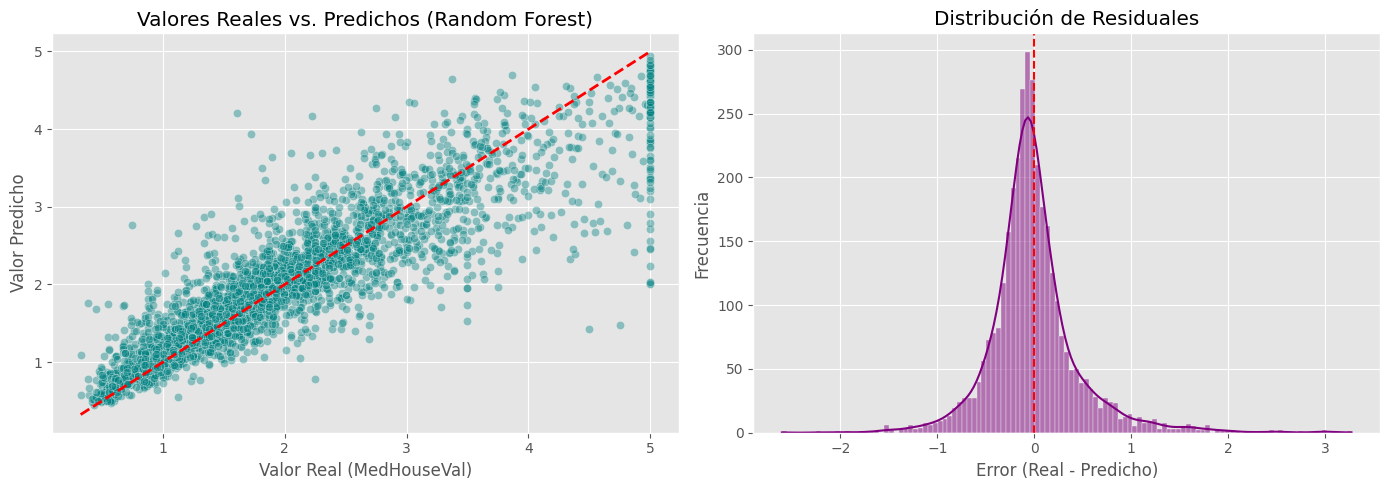

In [ ]:
# Gráficos del Mejor Modelo (Random Forest)
y_pred_best = y_pred_rf
residuales = y_test - y_pred_best

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter Real vs Predicho
sns.scatterplot(x=y_test, y=y_pred_best, alpha=0.4, color='teal', ax=axes[0])
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_title('Valores Reales vs. Predichos (Random Forest)')
axes[0].set_xlabel('Valor Real (MedHouseVal)')
axes[0].set_ylabel('Valor Predicho')

# Histograma de Residuales
sns.histplot(residuales, kde=True, color='purple', ax=axes[1])
axes[1].axvline(0, color='r', linestyle='--')
axes[1].set_title('Distribución de Residuales')
axes[1].set_xlabel('Error (Real - Predicho)')
axes[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.savefig('figures/evaluacion_modelo.png', dpi=150)
plt.show()

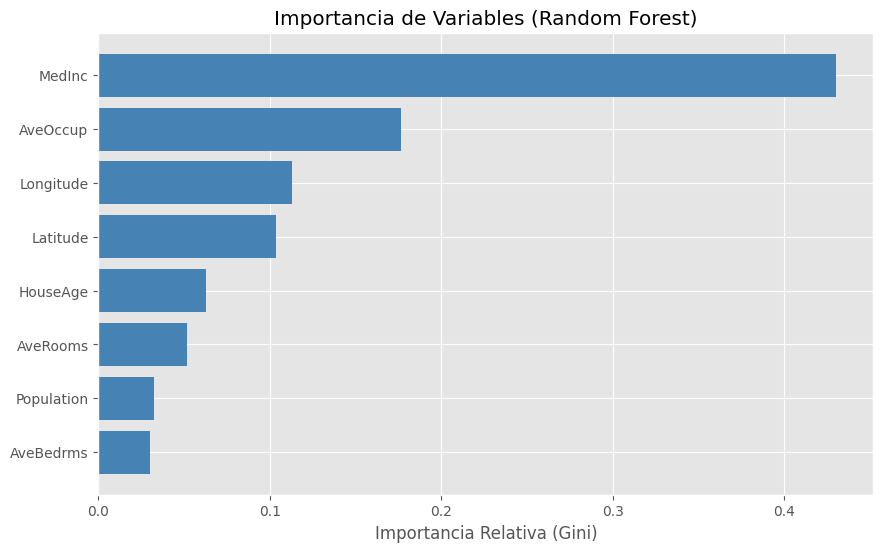


--- Top 10 Observaciones con Mayor Error Absoluto ---


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Real_MedHouseVal,Pred_MedHouseVal,Error_Absoluto
16556,3.729,6.0,4.583,1.083,69.0,2.875,37.80,-121.29,4.750,1.480,3.270
19542,1.768,39.0,5.000,0.889,22.0,2.444,37.63,-120.92,4.500,1.426,3.074
18464,4.204,11.0,6.754,1.031,881.0,4.613,37.19,-121.74,5.000,2.011,2.989
12069,4.239,6.0,7.723,1.169,228.0,3.508,33.83,-117.55,5.000,2.024,2.976
10454,2.385,22.0,5.153,1.146,334.0,2.127,33.48,-117.66,5.000,2.036,2.964
15624,2.588,52.0,3.287,1.020,629.0,2.547,37.80,-122.41,5.000,2.236,2.764
6029,5.227,52.0,6.270,1.044,444.0,2.176,34.07,-117.75,1.610,4.213,2.603
17819,1.736,42.0,3.000,1.000,26.0,1.857,37.39,-121.90,5.000,2.458,2.542
16987,4.704,17.0,3.238,1.042,683.0,1.674,37.55,-122.26,5.000,2.466,2.534
6376,4.180,43.0,6.345,1.060,674.0,2.524,34.15,-118.03,4.868,2.413,2.455


In [ ]:
# Importancia de Variables (Feature Importances)
importancias = grid_rf.best_estimator_.feature_importances_
df_importancias = pd.DataFrame({'Variable': vars_num, 'Importancia': importancias}).sort_values(by='Importancia', ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(df_importancias['Variable'], df_importancias['Importancia'], color='steelblue')
plt.title('Importancia de Variables (Random Forest)')
plt.xlabel('Importancia Relativa (Gini)')
plt.savefig('figures/importancia_variables.png', dpi=150)
plt.show()

# Análisis de las 10 peores predicciones (mayor error absoluto)
errores_absolutos = np.abs(residuales)
df_errores = X_test.copy()
df_errores['Real_MedHouseVal'] = y_test
df_errores['Pred_MedHouseVal'] = y_pred_best
df_errores['Error_Absoluto'] = errores_absolutos

top_10_peores = df_errores.sort_values(by='Error_Absoluto', ascending=False).head(10)
print("\n--- Top 10 Observaciones con Mayor Error Absoluto ---")
display(top_10_peores.round(3))

### Selección del Mejor Modelo
Tras evaluar el desempeño en el conjunto de prueba, seleccionamos **Random Forest** como nuestro modelo predictivo definitivo. Su métrica principal ($R^2$ cercano a 0.80) supera enormemente el rendimiento de la regresión penalizada Ridge (que ronda el 0.60). Si bien el modelo de ensamble presenta un evidente mayor costo computacional en su etapa de entrenamiento (requiriendo varios minutos frente a los escasos segundos de Ridge) y sacrifica explicabilidad directa (es un modelo de "caja negra" comparado con los coeficientes lineales), el *trade-off* es sumamente favorable dado el salto significativo en precisión. Adicionalmente, el tiempo de inferencia sigue siendo instantáneo, lo que lo hace totalmente viable para un entorno de producción. Al observar y analizar las métricas entre validación cruzada y test, descartamos un sobreajuste severo.

### Análisis de las peores predicciones
Al revisar el top 10 de las observaciones con mayor error absoluto (con los residuales más altos), encontramos un patrón técnico clarísimo: en su gran mayoría, el valor real de la propiedad (`Real_MedHouseVal`) es exactamente **5.0** (que equivale al tope de $500,000 USD).
    
Esta característica en común explica por qué nuestro algoritmo falla de manera tan pronunciada en estas instancias: el dataset original tiene un límite artificial en ese precio. Todas las propiedades con valor real en el mercado que fuesen superior a medio millón de dólares fueron truncadas a 5.0. Nuestro modelo, al identificar variables predictoras fuertes (como altos ingresos en coordenadas geográficas exclusivas), predice valores que lógicamente superarían ese techo. Al contrastar esta predicción realista contra la etiqueta censurada (5.0), se genera matemáticamente un falso residuo elevado.

## Conclusiones Ejecutivas

Tras completar este pipeline de Machine Learning con el dataset de **California Housing**, destaco los siguientes puntos clave del análisis:

### 1. Hallazgos del EDA y Clustering
* **Limpieza y Correlación:** El dataset venía limpio de nulos, pero con outliers fuertes que fueron limpiados usando el método IQR para no sesgar los modelos. Al cruzar las variables, notamos de inmediato que el ingreso medio (`MedInc`) es el predictor más fuerte del valor de una propiedad.
* **Patrones No Supervisados:** Aplicamos PCA (5 componentes, reteniendo >80% de varianza) y luego K-Means ($K=2$). Fue interesante ver cómo el algoritmo segmentó el estado en Norte y Sur automáticamente, guiándose meramente por las coordenadas espaciales sin que le dieramos etiquetas.

### 2. Modelo Seleccionado y Variables Top
Nos quedamos definitivamente con el modelo **Random Forest Regressor**. Aunque demoró casi 13 minutos en entrenar buscando hiperparámetros, logró un $R^2$ cercano a 0.80, superando por mucho el 0.62 de Ridge. Las 3 variables que más peso tuvieron en el modelo fueron:
1. **MedInc (Ingreso Medio):** Confirma que el poder adquisitivo del sector es el factor número uno para tasar una casa.
2. **Longitude (Longitud)** y **3. Latitude (Latitud):** En conjunto, demuestran que la ubicación exacta en el mapa (ej. cercanía a la costa o ciudades principales) es el segundo factor más crítico.

### 3. Limitaciones del Estudio
* **Tope artificial en los precios:** Las casas sobre $500,000 USD venían truncadas a un valor máximo de 5.0. Esto nos disparó el error absoluto al intentar predecir el valor de propiedades de lujo.
* **Data antigua:** Son datos del censo de 1990, al ser tan antiguo no reflejan el mercado inmobiliario moderno actual ni la inflación.
* **Modelos de caja negra:** Random Forest nos dio precisión, pero perdimos la explicabilidad directa de los coeficientes lineales y tuvimos un alto costo computacional.

### 4. Recomendaciones y Trabajo Futuro
* **Recomendaciones:** Para un entorno productivo real, se sugieren levantar los datos sin aplicar límites artificiales en los precios más altos. Además, sería importante e ideal enriquecer la base cruzándola con variables económicas actuales (como inflación o tasas de interés).
* **Trabajo Futuro:** Como próximo paso, propongo implementar algoritmos de Gradient Boosting (como XGBoost). Tal como hemos visto en otros proyectos de clasificación, esto nos permitiría aplicar *early stopping* para reducir drásticamente los tiempos de entrenamiento, intentando mantener la alta precisión que ya logramos con los árboles.